<a href="https://colab.research.google.com/github/dolmaengiee/HJG/blob/main/%ED%99%98%EC%A0%95%EA%B3%B51.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

In [ ]:
print(torch.__version__)

2.10.0+cpu


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.utils import save_image

In [ ]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz -O facades.tar.gz
!tar -zxvf facades.tar.gz -C ./

--2026-05-11 05:39:47--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30168306 (29M) [application/x-gzip]
Saving to: ‘facades.tar.gz’

facades.tar.gz      100%[===================>]  28.77M  1.26MB/s    in 25s     

2026-05-11 05:40:13 (1.13 MB/s) - ‘facades.tar.gz’ saved [30168306/30168306]

facades/
facades/test/
facades/test/27.jpg
facades/test/5.jpg
facades/test/72.jpg
facades/test/1.jpg
facades/test/10.jpg
facades/test/100.jpg
facades/test/101.jpg
facades/test/102.jpg
facades/test/103.jpg
facades/test/104.jpg
facades/test/105.jpg
facades/test/106.jpg
facades/test/11.jpg
facades/test/12.jpg
facades/test/13.jpg
facades/test/14.jpg
facades/test/15.jpg
facades/test/16.jpg
facades/test/17.jpg
facades/test/18.jpg
facades/te

In [ ]:
print("학습 데이터셋 A와 B의 개수:", len(next(os.walk('./facades/train/'))[2]))
print("평가 데이터셋 A와 B의 개수:", len(next(os.walk('./facades/val/'))[2]))
print("테스트 데이터셋 A와 B의 개수:", len(next(os.walk('./facades/test/'))[2]))

학습 데이터셋 A와 B의 개수: 400
평가 데이터셋 A와 B의 개수: 100
테스트 데이터셋 A와 B의 개수: 106


이미지 크기 (512, 256)


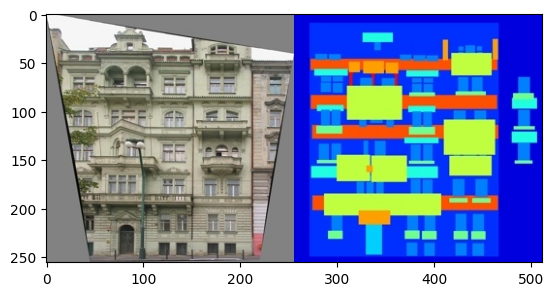

In [ ]:
image = Image.open('./facades/train/100.jpg')
print("이미지 크기", image.size)

plt.imshow(image)
plt.show()
#오른쪽 사진을 통해 왼쪽 사진을 그리도록 학습시킴

In [ ]:
class ImageDataset(Dataset):
  def __init__(self, root,transforms_=None, mode="train"):
    self.transform = transforms_
    self.files = sorted(glob.glob(os.path.join(root, mode) + "/*.jpg"))
    if mode == "train":
      self.files.extend(sorted(glob.glob(os.path.join(root, "test") + "/*.jpg")))

  def __getitem__(self, index):
    img = Image.open(self.files[index % len(self.files)])
    w,h = img.size
    img_A = img.crop((0,0,w/2,h))
    img_B = img.crop((w/2,0,w,h))

    if np.random.random() < 0.5:
      img_A = Image.fromarray(np.array(img_A)[:,::-1,:], "RGB")
      img_B = Image.fromarray(np.array(img_B)[:,::-1,:],"RGB")

    img_A = self.transform(img_A)
    img_B = self.transform(img_B)

    return {"A": img_A, "B": img_B}

  def __len__(self):
    return len(self.files)

transforms_ = transforms.Compose([
    transforms.Resize((256,256), Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = ImageDataset("facades", transforms_ = transforms_)
val_dataset = ImageDataset("facades", transforms_ = transforms_)

train_dataloader = DataLoader(train_dataset, batch_size = 10, shuffle=True, num_workers=4)
val_dataloader = DataLoader(val_dataset, batch_size=10, shuffle=True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
class UNetDown(nn.Module):
  def __init__(self, in_channels, out_channels, normalize=True, dropout=0.0):
    super(UNetDown, self).__init__()
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
    if normalize:
      layers.append(nn.InstanceNorm2d(out_channels))
    layers.append(nn.LeakyReLU(0.2))
    if dropout:
      layers.append(nn.Dropout(dropout))
    self.model = nn.Sequential(*layers)

  def forward(self, x):
    return self.model(x)

class UNetUp(nn.Module):
  def __init__(self, in_channels, out_channels, dropout=0.0):
    super(UNetUp, self).__init__()
    layers = [nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
    layers.append(nn.InstanceNorm2d(out_channels))
    layers.append(nn.ReLU(inplace=True))
    if dropout:
      layers.append(nn.Dropout(dropout))
    self.model = nn.Sequential(*layers)

  def forward(self, x, skip_input):
    x = self.model(x)
    x = torch.cat((x,skip_input),1)

    return x

class GeneratorUNet(nn.Module):
  def __init__(self, in_channels=3, out_channels=3):
    super(GeneratorUNet, self).__init__()

    self.down1 = UNetDown(in_channels, 64, normalize=False)
    self.down2 = UNetDown(64,128)
    self.down3 = UNetDown(128,256)
    self.down4 = UNetDown(256,512, dropout = 0.5)
    self.down5 = UNetDown(512,512, dropout = 0.5)
    self.down6 = UNetDown(512,512, dropout = 0.5)
    self.down7 = UNetDown(512,512, dropout = 0.5)
    self.down8 = UNetDown(512,512, normalize = False,dropout = 0.5)

    self.up1 = UNetUp(512,512,dropout=0.5)
    self.up2 = UNetUp(1024,512,dropout=0.5)
    self.up3 = UNetUp(1024,512,dropout=0.5)
    self.up4 = UNetUp(1024,512,dropout=0.5)
    self.up5 = UNetUp(1024,256)
    self.up6 = UNetUp(512,128)
    self.up7 = UNetUp(256,64)
    self.final = nn.Sequential(
        nn.Upsample(scale_factor=2),
        nn.ZeroPad2d((1,0,1,0)),
        nn.Conv2d(128,out_channels, kernel_size=4,padding=1),
        nn.Tanh()
    )

In [ ]:
def forward(self, x):
  d1 = self.down1(x)
  d2 = self.down2(d1)
  d3 = self.down3(d2)
  d4 = self.down4(d3)
  d5 = self.down5(d4)
  d6 = self.down6(d5)
  d7 = self.down7(d6)
  d8 = self.down8(d7)
  u1 = self.up1(d8, d7)
  u2 = self.up2(u1, d6)
  u3 = self.up3(u2, d5)
  u4 = self.up4(u3, d4)
  u5 = self.up5(u4, d3)
  u6 = self.up6(u5, d2)
  u7 = self.up7(u6, d1)

  return self.final(u7)

class Discriminator(nn.Module):
  def __init__(self, in_channels=3):
    super(Discriminator, self).__init__()

    def discriminator_block(in_channels, out_channels, normalization=True):
# 너비와 높이가 2배씩 감소
      layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)]
      if normalization:
      layers.append(nn.InstanceNorm2d(out_channels))
      layers.append(nn.LeakyReLU(0.2, inplace=True))
      return layers
  self.model = nn.Sequential(
# 두 개의 이미지(실제/변환된 이미지, 조건 이미지)를 입력 받으므로 입력 채널의 크기는 2배
    *discriminator_block(in_channels * 2, 64, normalization=False), # 출력: [64 X 128 X 128]
    *discriminator_block(64, 128), # 출력: [128 X 64 X 64]
    *discriminator_block(128, 256), # 출력: [256 X 32 X 32]
    *discriminator_block(256, 512), # 출력: [512 X 16 X 16]
    nn.ZeroPad2d((1, 0, 1, 0)),
    nn.Conv2d(512, 1, kernel_size=4, padding=1, bias=False) # 출력: [1 X 16 X 16]
    )

 def forward(self, img_A, img_B):
# 이미지 두 개를 채널 레벨에서 연결하여(concatenate) 입력 데이터 생성
  img_input = torch.cat((img_A, img_B), 1)
  return self.model(img_input)
  )